## Image Classification using Pytorch

In [31]:
from google.colab import files

files.download('cat_image.jpg')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import kagglehub

# Download latest version

path = kagglehub.dataset_download("andrewmvd/animal-faces")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animal-faces' dataset.
Path to dataset files: /kaggle/input/animal-faces


In [4]:
!pip install opendatasets --quiet

import opendatasets as od

od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bharathvankayala
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:13<00:00, 52.5MB/s]


In [5]:
pip install Pillow


In [6]:
""" Importing All Libraries and Functions """

import torch

from torch import nn

from torch.optim import Adam

import torchvision.transforms as transforms

from torch.utils.data  import Dataset , DataLoader

from sklearn.preprocessing import LabelEncoder

from PIL import Image

import matplotlib.pyplot as plt

import pandas as pd

import numpy  as np

import os

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

cuda


In [8]:
image_path = []

labels = []

for i in os.listdir("/content/animal-faces/afhq/"):

  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):

    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):

      labels.append(label)

      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")


data = pd.DataFrame(zip(image_path, labels), columns = ['image_paths', 'labels'])

data.head()

,image_paths,labels
0,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
1,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
2,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
3,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
4,/content/animal-faces/afhq/train/dog/pixabay_d...,dog


Spliting an DataSet

In [9]:
from sklearn.model_selection import train_test_split

# Split data into training and a temporary set

train, temp_test_val = train_test_split(data, test_size=0.3, random_state=7)

# Split the temporary set into validation

val, test = train_test_split(temp_test_val, test_size=0.5, random_state=7)

In [10]:
label_encoder = LabelEncoder()

label_encoder.fit(data['labels'])

transform = transforms.Compose([
    transforms.Resize((128 , 128)) ,

    transforms.ToTensor() ,

    transforms.ConvertImageDtype(torch.float)
])

Custom DataSet Class

In [11]:
class CustomImageDataset(Dataset):

  def __init__(self , dataframe , transform = None):

    self.dataframe = dataframe

    self.transform = transform

    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self) :

    return self.dataframe.shape[0]

  def __getitem__(self , idx) :

    img_path = self.dataframe.iloc[idx , 0]

    labels = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform :

      image = self.transform(image).to(device)

    return image , labels

In [12]:
""" creating DataSet Objects """

train_dataset = CustomImageDataset(dataframe = train , transform = transform)

val_dataset = CustomImageDataset(dataframe = val , transform = transform)

test_dataset = CustomImageDataset(dataframe = test , transform = transform)

Visualize Images

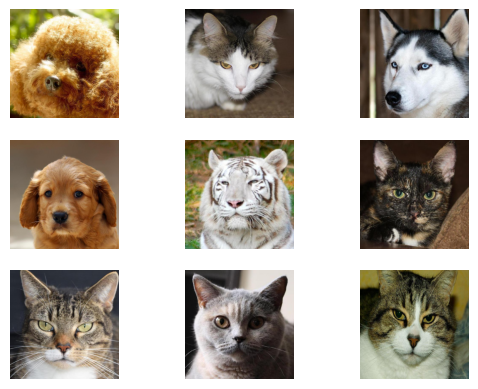

In [13]:
n_rows = 3

n_cols = 3

f , axarr = plt.subplots(n_rows , n_cols)

for row in range(n_rows):

  for col in range(n_cols):

    image = Image.open(data.sample(n=1)["image_paths"].iloc[0]).convert("RGB")

    axarr[row , col].imshow(image)

    axarr[row , col].axis('off')

plt.show()

In [14]:
""" Data LOaders """

train_loader = DataLoader(train_dataset , batch_size = 16 , shuffle = True )

val_loader = DataLoader(val_dataset , batch_size = 16 , shuffle = True)

test_loader = DataLoader(test_dataset , batch_size = 16 , shuffle = True)

## Building CNN Model

In [15]:
class Net(nn.Module):

  def __init__(self):

    super().__init__()

    self.conv1 = nn.Conv2d(3 , 32 , kernel_size = 3 , padding = 1 )

    self.conv2 = nn.Conv2d(32 , 64 , kernel_size = 3 , padding = 1)

    self.conv3 = nn.Conv2d(64 , 128 , kernel_size = 3 , padding = 1)

    self.pooling = nn.MaxPool2d(2 , 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()

    self.linear = nn.Linear(( 128 * 16 * 16) , 128)

    self.output = nn.Linear(128 , len(data['labels'].unique()))


  def  forward(self , x):

    x = self.conv1(x)

    x = self.pooling(x)

    x = self.relu(x)

    x = self.conv2(x)

    x = self.pooling(x)

    x = self.relu(x)

    x = self.conv3(x)

    x = self.pooling(x)

    x = self.relu(x)

    x = self.flatten(x)

    x = self.linear(x)

    x = self.relu(x)

    x = self.output(x)

    return x

In [17]:
model = Net().to(device)

Model summary

In [18]:
from torchsummary import summary

summary(model, input_size = (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
             ReLU-12                  [-1, 128]               0
           Linear-13                    [-1, 3]             387
Total params: 4,288,067
Trainable param

In [19]:
""" Loss Function and Optimizer """

loss = nn.CrossEntropyLoss()

optimizer = Adam(params = model.parameters() , lr = 0.001)

## Training and Validation loop

In [22]:
train_loss = []

train_acc = []

val_loss = []

val_acc = []

""" Accuracy of model can be increased by increasing the number of epochs """

for epoch in range(10) :

  total_acc_train = 0

  total_loss_train = 0

  total_loss_val = 0

  total_acc_val = 0

  for data in train_loader :

    inputs , labels = data

    optimizer.zero_grad()

    outputs = model(inputs)

    loss_train = loss(outputs , labels)

    total_loss_train += loss_train.item()

    loss_train.backward()

    acc_train = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += acc_train

    optimizer.step()

  with torch.no_grad() :

    for inputs , labels in val_loader:

      outputs = model(inputs)

      loss_val = loss(outputs , labels)

      total_loss_val += loss_val.item()

      loss_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

      total_acc_val  += loss_acc


  train_loss.append(round(total_loss_train/1000, 4))

  train_acc.append(round(total_acc_train/(train_dataset.__len__())*100, 4))

  val_loss.append(round(total_loss_val/1000, 4))

  val_acc.append(round(total_acc_val/(val_dataset.__len__())*100, 4))

  print(f"Epoch {epoch+1}: Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_acc[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}")

Epoch 1: Train Loss: 0.0760, Train Acc: 96.0942, Val Loss: 0.0191, Val Acc: 95.3286
Epoch 2: Train Loss: 0.0422, Train Acc: 97.9630, Val Loss: 0.0227, Val Acc: 95.4527
Epoch 3: Train Loss: 0.0296, Train Acc: 98.3970, Val Loss: 0.0210, Val Acc: 95.3286
Epoch 4: Train Loss: 0.0193, Train Acc: 99.0346, Val Loss: 0.0168, Val Acc: 96.2795
Epoch 5: Train Loss: 0.0147, Train Acc: 99.1852, Val Loss: 0.0236, Val Acc: 96.2381
Epoch 6: Train Loss: 0.0142, Train Acc: 99.3003, Val Loss: 0.0298, Val Acc: 95.4940
Epoch 7: Train Loss: 0.0085, Train Acc: 99.6457, Val Loss: 0.0257, Val Acc: 95.6594
Epoch 8: Train Loss: 0.0123, Train Acc: 99.4775, Val Loss: 0.0239, Val Acc: 95.8247
Epoch 9: Train Loss: 0.0131, Train Acc: 99.3889, Val Loss: 0.0225, Val Acc: 96.2795
Epoch 10: Train Loss: 0.0087, Train Acc: 99.5926, Val Loss: 0.0419, Val Acc: 94.7912


In [24]:
with torch.no_grad():

  test_loss = 0

  test_acc = 0

  for inputs , labels in test_loader:

    predictions = model(inputs)

    acc = (torch.argmax(predictions , axis = 1)==labels).sum().item()

    test_acc += acc

    batch_loss = loss(predictions , labels)

    test_loss += batch_loss.item()



print(f"Accuracy Score is: {round((test_acc/test_dataset.__len__()) * 100, 4)} and Loss is {round(test_loss/1000, 4)}")


Accuracy Score is: 95.8264 and Loss is 0.0301


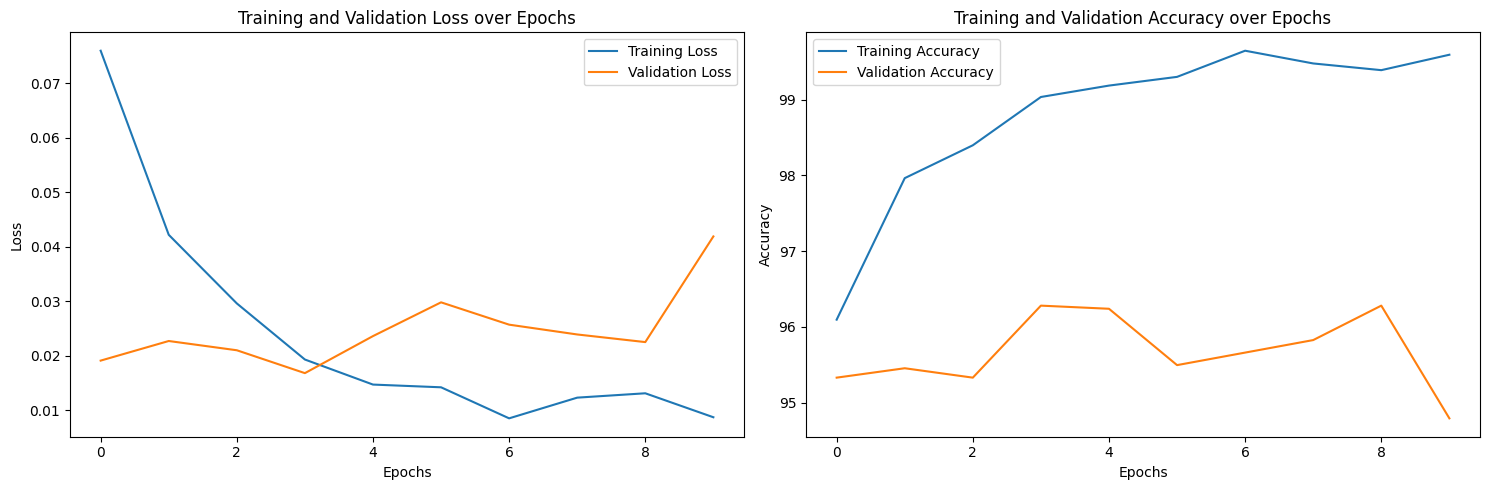

In [28]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(train_loss, label='Training Loss')
axs[0].plot(val_loss, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(train_acc, label='Training Accuracy')
axs[1].plot(val_acc, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()

## Testing with new data

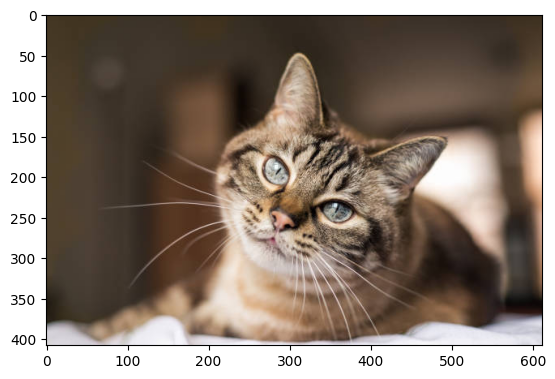


Predictions


array(['cat'], dtype=object)

In [33]:
"""  1. Read Image

     2. Transform using transform object

     3. predict through model

     4. inverse transform output

     """

def predict_image(image_path):

  image = Image.open(image_path).convert('RGB')

  image = transform(image).to(device)

  output = model(image.unsqueeze(0))

  output = torch.argmax(output , axis = 1).item()

  return label_encoder.inverse_transform([output])


# predictions

# visualize image

image = Image.open("cat_image.jpg")

plt.imshow(image)

plt.show()

print()

print("Predictions")

predict_image("cat_image.jpg")